<a href="https://colab.research.google.com/github/khushidevi7051-cmd/AI-ML-Project/blob/main/Credit_Card_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost imbalanced -learn openpyxl


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -l


In [5]:
!pip install ucimlrepo

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [8]:
print("\nDownloading UCI Credit Card Default Dataset...")

dataset = fetch_ucirepo(id=350)

X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

print("Dataset downloaded successfully!")


Dataset downloaded successfully!


In [9]:
df = pd.concat([X_raw, y_raw], axis=1)

# Clean column names
df.columns = df.columns.astype(str).str.strip()

print("\nDataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())


Dataset Shape: (30000, 24)

First 5 Rows:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [10]:
target_candidates = [
    col for col in df.columns
    if "Y" == col
]

print("\nPossible target columns:", target_candidates)

# Check if target_candidates is empty and handle it
if not target_candidates:
    print("Error: No target column found. Please check column names.")
    # You might want to raise an error or set a default value here
    target = None # Or handle as appropriate
else:
    target = target_candidates[-1]

print("Target selected:", target)


Possible target columns: ['Y']
Target selected: Y


In [11]:
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum().sum())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  

In [12]:
print("\nMissing-value checking completed.")


Missing-value checking completed.


In [13]:
# ============================================================
# 8. REMOVE ID COLUMN
# ============================================================
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

print("\nShape after removing ID:", df.shape)



Shape after removing ID: (30000, 24)



Target Distribution BEFORE SMOTE:
Y
0    23364
1     6636
Name: count, dtype: int64

Target Percentage:
Y
0    77.88
1    22.12
Name: proportion, dtype: float64


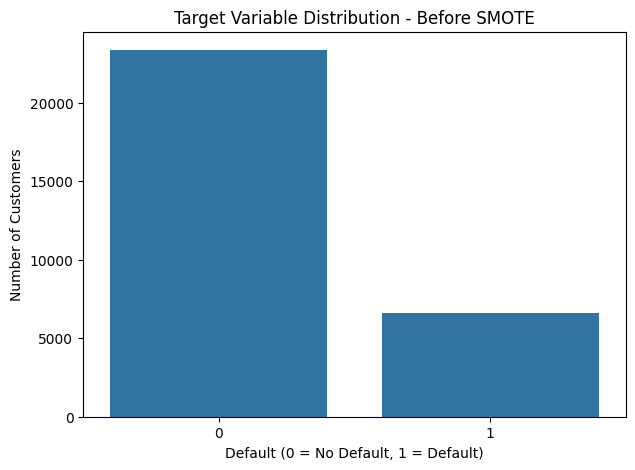

In [14]:

# ============================================================
# 9. TARGET DISTRIBUTION - BEFORE SMOTE
# ============================================================
print("\nTarget Distribution BEFORE SMOTE:")
print(df[target].value_counts())

print("\nTarget Percentage:")
print(
    df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# -----------------------------
# Target Distribution Graph
# -----------------------------
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x=target
)

plt.title("Target Variable Distribution - Before SMOTE")
plt.xlabel("Default (0 = No Default, 1 = Default)")
plt.ylabel("Number of Customers")

plt.show()

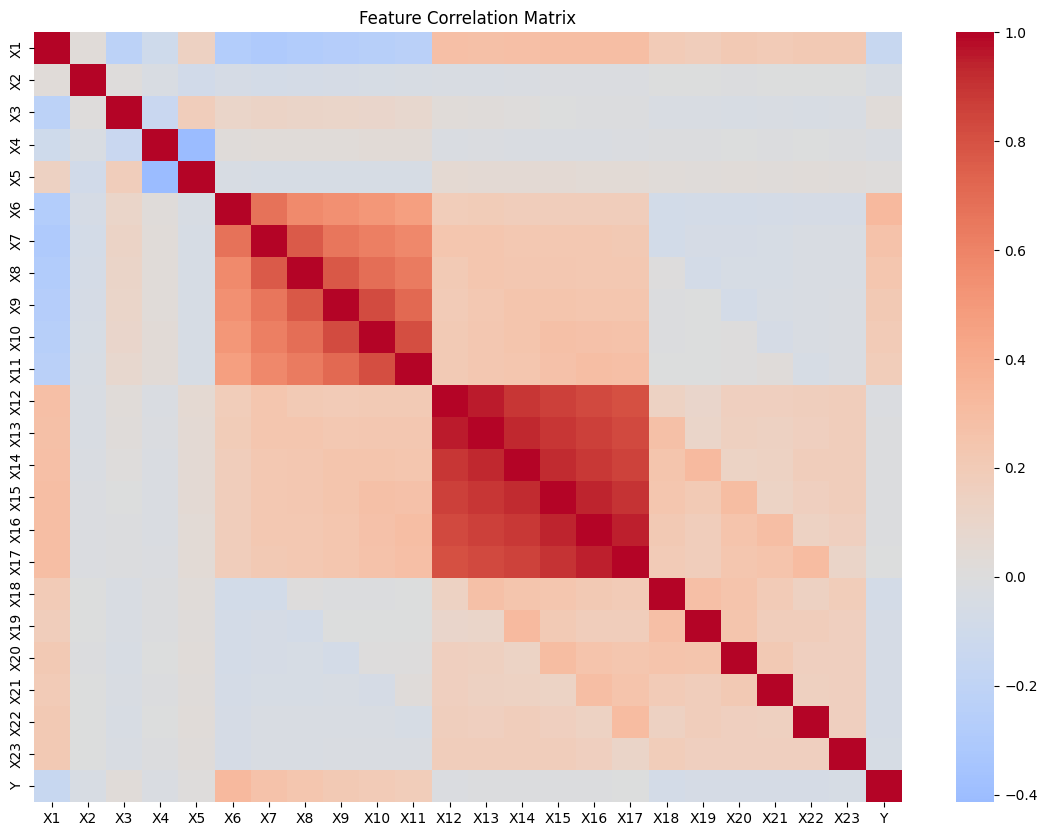

In [15]:
# ============================================================
# 10. EDA - CORRELATION MATRIX
# ============================================================
plt.figure(figsize=(14,10))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [16]:

# ============================================================
# 11. OUTLIER DETECTION
# ============================================================
# Display boxplots for important numerical variables

important_columns = [
    col for col in [
        "LIMIT_BAL",
        "AGE",
        "BILL_AMT1",
        "PAY_AMT1"
    ]
    if col in df.columns
]

for col in important_columns:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Outlier Detection - {col}")
    plt.xlabel(col)

    plt.show()


In [17]:

# ============================================================
# 12. SEPARATE FEATURES AND TARGET
# ============================================================
X = df.drop(columns=[target])
y = df[target]

print("\nFeatures:", X.shape)
print("Target:", y.shape)


Features: (30000, 23)
Target: (30000,)


In [18]:

# ============================================================
# 13. TRAIN-TEST SPLIT - 80/20
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n80/20 Train-Test Split")
print("Training:", X_train.shape)
print("Testing :", X_test.shape)


80/20 Train-Test Split
Training: (24000, 23)
Testing : (6000, 23)


In [19]:
# ============================================================
# 14. IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ============================================================
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("\nNumerical Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))


Numerical Features: 23
Categorical Features: 0


In [20]:



# ============================================================
# 15. PREPROCESSING
#     - Missing value handling
#     - StandardScaler
#     - One-Hot Encoding
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numerical",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("\nPreprocessing pipeline created.")


Preprocessing pipeline created.


In [22]:
# ============================================================
# 15. PREPROCESSING
#     - Missing value handling
#     - StandardScaler
#     - One-Hot Encoding
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numerical",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("\nPreprocessing pipeline created.")




Preprocessing pipeline created.


In [23]:
# ============================================================
# 16. LOGISTIC REGRESSION
# ============================================================
lr_pipeline = ImbPipeline([
    ("preprocessing", preprocessor),

    ("smote", SMOTE(random_state=42)),

    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

print("\nTraining Logistic Regression...")

lr_pipeline.fit(
    X_train,
    y_train
)

y_pred_lr = lr_pipeline.predict(X_test)

y_prob_lr = lr_pipeline.predict_proba(
    X_test
)[:, 1]


Training Logistic Regression...


In [24]:
# ============================================================
# 17. RANDOM FOREST
# ============================================================
rf_pipeline = ImbPipeline([
    ("preprocessing", preprocessor),

    ("smote", SMOTE(random_state=42)),

    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

print("Training Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

y_pred_rf = rf_pipeline.predict(X_test)

y_prob_rf = rf_pipeline.predict_proba(
    X_test
)[:, 1]


Training Random Forest...


In [25]:


# ============================================================
# 18. XGBOOST
# ============================================================
xgb_pipeline = ImbPipeline([
    ("preprocessing", preprocessor),

    ("smote", SMOTE(random_state=42)),

    (
        "model",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

print("Training XGBoost...")

xgb_pipeline.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(
    X_test
)[:, 1]

Training XGBoost...


In [26]:
# ============================================================
# 19. MODEL EVALUATION FUNCTION
# ============================================================
def evaluate_model(
    name,
    y_true,
    y_pred,
    y_probability
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall   : {recall*100:.2f}%")
    print(f"F1 Score : {f1*100:.2f}%")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

In [27]:

# ============================================================
# 20. EVALUATE ALL THREE MODELS
# ============================================================
lr_results = evaluate_model(
    "LOGISTIC REGRESSION",
    y_test,
    y_pred_lr,
    y_prob_lr
)

rf_results = evaluate_model(
    "RANDOM FOREST",
    y_test,
    y_pred_rf,
    y_prob_rf
)

xgb_results = evaluate_model(
    "XGBOOST",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)


LOGISTIC REGRESSION
Accuracy : 67.23%
Precision: 36.14%
Recall   : 62.77%
F1 Score : 45.87%
ROC-AUC  : 0.7104

RANDOM FOREST
Accuracy : 79.70%
Precision: 54.77%
Recall   : 47.17%
F1 Score : 50.69%
ROC-AUC  : 0.7528

XGBOOST
Accuracy : 80.48%
Precision: 57.69%
Recall   : 44.08%
F1 Score : 49.98%
ROC-AUC  : 0.7657


In [28]:

# ============================================================
# 21. MODEL COMPARISON TABLE
# ============================================================
results = pd.DataFrame(
    [
        lr_results,
        rf_results,
        xgb_results
    ],

    columns=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    index=[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ]
)

print("\nMODEL PERFORMANCE COMPARISON")

display(
    (results * 100).round(2)
)



MODEL PERFORMANCE COMPARISON


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,67.23,36.14,62.77,45.87,71.04
Random Forest,79.70,54.77,47.17,50.69,75.28
XGBoost,80.48,57.69,44.08,49.98,76.57


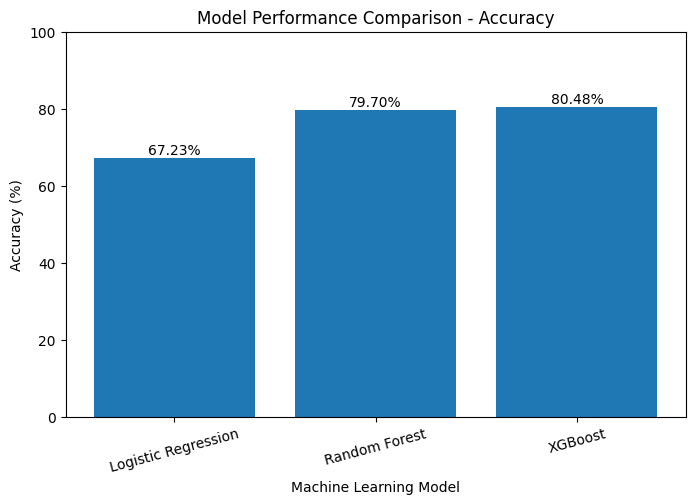

In [29]:

# ============================================================
# 22. ACCURACY COMPARISON GRAPH
# ============================================================
plt.figure(figsize=(8,5))

accuracy_values = results["Accuracy"] * 100

plt.bar(
    results.index,
    accuracy_values
)

plt.title(
    "Model Performance Comparison - Accuracy"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.ylim(0,100)

for i, value in enumerate(
    accuracy_values
):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)

plt.show()

In [30]:

# ============================================================
# 23. GRIDSEARCHCV - MODEL TUNING
# ============================================================
print("\nStarting GridSearchCV...")
print("Using 5-Fold Cross Validation...")

param_grid = {

    "model__n_estimators": [
        200,
        300
    ],

    "model__max_depth": [
        3,
        5
    ],

    "model__learning_rate": [
        0.05,
        0.1
    ]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(

    estimator=xgb_pipeline,

    param_grid=param_grid,

    scoring="recall",

    cv=cv,

    n_jobs=-1,

    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Recall:")
print(
    f"{grid_search.best_score_*100:.2f}%"
)


Starting GridSearchCV...
Using 5-Fold Cross Validation...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}

Best Cross-Validation Recall:
51.16%


In [31]:

# ============================================================
# 24. OPTIMIZED XGBOOST
# ============================================================
best_xgb = grid_search.best_estimator_

y_pred_best = best_xgb.predict(
    X_test
)

y_prob_best = best_xgb.predict_proba(
    X_test
)[:, 1]


In [32]:



# ============================================================
# 25. FINAL RESULTS
# ============================================================
final_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

final_precision = precision_score(
    y_test,
    y_pred_best
)

final_recall = recall_score(
    y_test,
    y_pred_best
)

final_f1 = f1_score(
    y_test,
    y_pred_best
)

final_roc_auc = roc_auc_score(
    y_test,
    y_prob_best
)

print("\n")
print("="*60)
print("FINAL OPTIMIZED XGBOOST RESULTS")
print("="*60)

print(
    f"Accuracy : {final_accuracy*100:.2f}%"
)

print(
    f"Precision: {final_precision*100:.2f}%"
)

print(
    f"Recall   : {final_recall*100:.2f}%"
)

print(
    f"F1 Score : {final_f1*100:.2f}%"
)

print(
    f"ROC-AUC  : {final_roc_auc:.4f}"
)




FINAL OPTIMIZED XGBOOST RESULTS
Accuracy : 79.52%
Precision: 53.95%
Recall   : 50.41%
F1 Score : 52.12%
ROC-AUC  : 0.7671


In [33]:

# ============================================================
# 26. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "No Default",
            "Default"
        ]
    )
)



Classification Report:
              precision    recall  f1-score   support

  No Default       0.86      0.88      0.87      4673
     Default       0.54      0.50      0.52      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.69      0.70      6000
weighted avg       0.79      0.80      0.79      6000



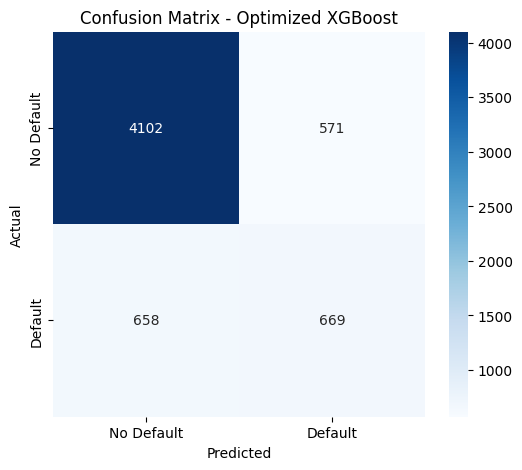

In [35]:
 # ============================================================
# 27. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",

    xticklabels=[
        "No Default",
        "Default"
    ],

    yticklabels=[
        "No Default",
        "Default"
    ]
)

plt.title(
    "Confusion Matrix - Optimized XGBoost"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


<Figure size 800x600 with 0 Axes>

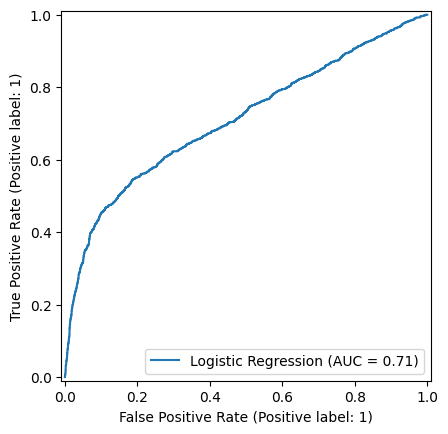

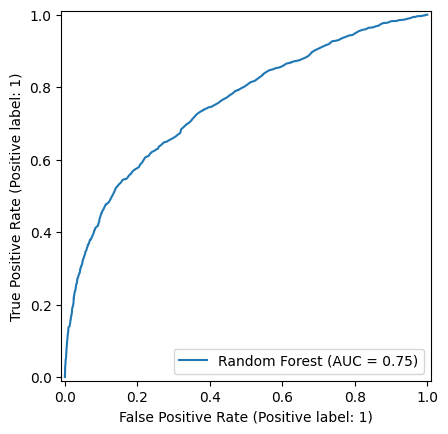

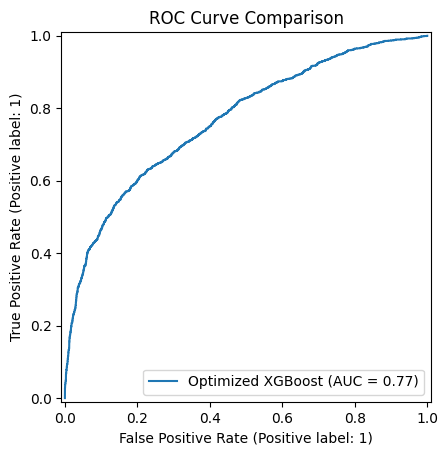

In [36]:


# ============================================================
# 28. ROC CURVE
# ============================================================
plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_best,
    name="Optimized XGBoost"
)

plt.title(
    "ROC Curve Comparison"
)

plt.show()

In [37]:

# ============================================================
# 29. TOP 15 FEATURES
# ============================================================
# Get transformed feature names

preprocessor_fitted = best_xgb.named_steps[
    "preprocessing"
]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

model = best_xgb.named_steps[
    "model"
]

importance = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

print("\nTop 15 Most Important Features:")
display(
    importance.head(15)
)


Top 15 Most Important Features:


,0
numerical__X6,0.137195
numerical__X7,0.084951
numerical__X8,0.083153
numerical__X3,0.062613
numerical__X10,0.057498
numerical__X9,0.057165
numerical__X19,0.053102
numerical__X1,0.052125
numerical__X11,0.049507
numerical__X18,0.043307


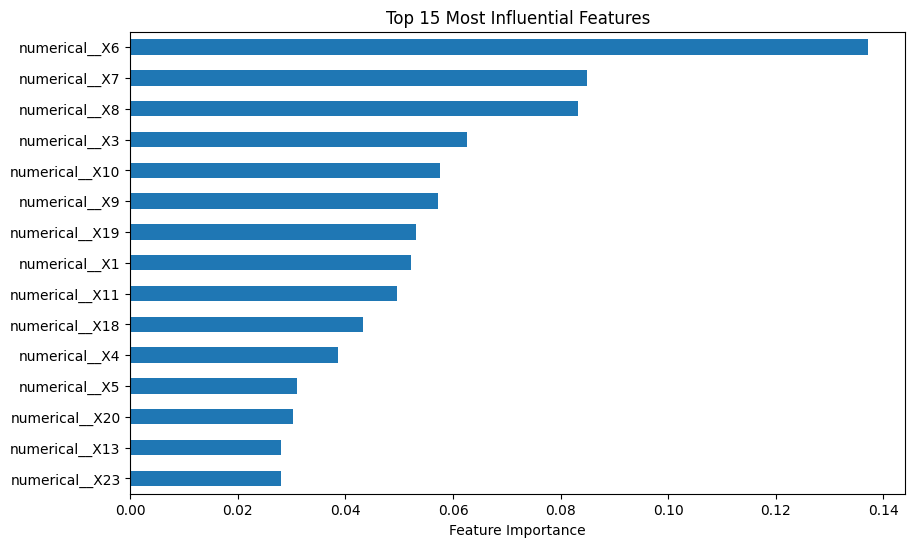

In [38]:
# ============================================================
# 30. TOP 15 FEATURE GRAPH
# ============================================================
plt.figure(figsize=(10,6))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 Most Influential Features"
)

plt.xlabel("Feature Importance")

plt.show()

In [39]:

# ============================================================
# 31. FINAL PROJECT SUMMARY
# ============================================================
print("\n")
print("="*60)
print("CREDIT CARD DEFAULT PREDICTION PROJECT COMPLETED")
print("="*60)

print("\nWorkflow:")
print("Data Collection")
print("      ↓")
print("EDA")
print("      ↓")
print("Data Cleaning")
print("      ↓")
print("Feature Engineering")
print("      ↓")
print("One-Hot Encoding + StandardScaler")
print("      ↓")
print("80/20 Train-Test Split")
print("      ↓")
print("SMOTE")
print("      ↓")
print("Logistic Regression")
print("      ↓")
print("Random Forest")
print("      ↓")
print("XGBoost")
print("      ↓")
print("GridSearchCV - 5 Fold")
print("      ↓")
print("Model Evaluation")
print("      ↓")
print("Optimized XGBoost")



CREDIT CARD DEFAULT PREDICTION PROJECT COMPLETED

Workflow:
Data Collection
      ↓
EDA
      ↓
Data Cleaning
      ↓
Feature Engineering
      ↓
One-Hot Encoding + StandardScaler
      ↓
80/20 Train-Test Split
      ↓
SMOTE
      ↓
Logistic Regression
      ↓
Random Forest
      ↓
XGBoost
      ↓
GridSearchCV - 5 Fold
      ↓
Model Evaluation
      ↓
Optimized XGBoost
